In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

In [ ]:
# Load the dataset
file_path = '/content/station 1611400dataaset.csv'  # Replace with the correct path if necessary
data = pd.read_csv(file_path)

# Show the first few rows of the dataset to verify
data.head()

,Date,Time (GMT),Highest,MHHW (ft),MHW (ft),MSL (ft),MTL (ft),MLW (ft),MLLW (ft),Lowest (ft),Inf
0,1955/10/01,00:00,2.113,1.575,1.175,0.643,0.614,0.062,-0.128,-0.486,0
1,1955/11/01,00:00,2.513,1.824,1.302,0.794,0.755,0.213,-0.075,-0.587,0
2,1955/12/01,00:00,2.415,1.713,1.155,0.623,0.584,0.013,-0.285,-0.787,0
3,1956/01/01,00:00,2.113,1.453,0.965,0.394,0.374,-0.207,-0.486,-0.886,0
4,1956/02/01,00:00,1.713,1.224,0.863,0.292,0.292,-0.285,-0.486,-0.787,0


In [ ]:
# Select numerical columns for PCA
numerical_data = data[['Highest', 'MHHW (ft)', 'MHW (ft)', 'MSL (ft)', 'MTL (ft)',
                       'MLW (ft)', 'MLLW (ft)', 'Lowest (ft)']]

# Standardizing the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numerical_data)

# Check the first few rows of the scaled data
scaled_data[:5]

array([[-0.798439  , -1.08166217, -1.1869706 , -0.86588476, -1.05440996,
        -0.84548545, -0.605279  , -0.52736263],
       [ 0.45455092, -0.10754094, -0.66814435, -0.22654628, -0.45031208,
        -0.18220378, -0.38935055, -0.89436528],
       [ 0.14756839, -0.54178775, -1.26867552, -0.95056535, -1.18294142,
        -1.06072255, -1.2449161 , -1.62110319],
       [-0.798439  , -1.55894245, -2.04487227, -1.92015814, -2.08266165,
        -2.02709321, -2.06381455, -1.98083846],
       [-2.05142892, -2.45482102, -2.46156736, -2.35202916, -2.43398098,
        -2.36971553, -2.06381455, -1.62110319]])

In [ ]:
from sklearn.impute import SimpleImputer
import numpy as np

# Check if there are any missing values in the dataset before imputation
print("Missing values before imputation:", np.sum(np.isnan(scaled_data)))

# Impute missing values with the mean of each column
imputer = SimpleImputer(strategy='mean')
scaled_data_imputed = imputer.fit_transform(scaled_data)

# Verify if there are any missing values left after imputation
print("Missing values after imputation:", np.sum(np.isnan(scaled_data_imputed)))

Missing values before imputation: 415
Missing values after imputation: 0


In [ ]:
# Perform PCA for 2 components
pca_2d = PCA(n_components=2)
pca_2d_result = pca_2d.fit_transform(scaled_data_imputed)

# Perform PCA for 3 components
pca_3d = PCA(n_components=3)
pca_3d_result = pca_3d.fit_transform(scaled_data_imputed)

In [ ]:
# Variance explained by the 2D PCA components
explained_variance_2d = pca_2d.explained_variance_ratio_
print(f"Variance explained by 2 components: {explained_variance_2d.sum() * 100:.2f}%")

# Variance explained by the 3D PCA components
explained_variance_3d = pca_3d.explained_variance_ratio_
print(f"Variance explained by 3 components: {explained_variance_3d.sum() * 100:.2f}%")

Variance explained by 2 components: 92.92%
Variance explained by 3 components: 97.50%


In [ ]:
# Finding the number of components for at least 95% variance
if cumulative_variance_2d[-1] >= 0.95:
    components_needed_95 = np.where(cumulative_variance_2d >= 0.95)[0][0] + 1
else:
    components_needed_95 = len(cumulative_variance_2d)  # If 95% variance is not reached, use all components

if cumulative_variance_3d[-1] >= 0.95:
    components_needed_95_3d = np.where(cumulative_variance_3d >= 0.95)[0][0] + 1
else:
    components_needed_95_3d = len(cumulative_variance_3d)  # If 95% variance is not reached, use all components

# Print the number of components required for at least 95% variance
print(f"Number of components needed to retain at least 95% variance (2D): {components_needed_95}")
print(f"Number of components needed to retain at least 95% variance (3D): {components_needed_95_3d}")

Number of components needed to retain at least 95% variance (2D): 2
Number of components needed to retain at least 95% variance (3D): 3


In [ ]:
# Top three eigenvalues for 2D PCA
top_3_eigenvalues = pca_2d.explained_variance_[:3]
print(f"Top 3 Eigenvalues: {top_3_eigenvalues}")

Top 3 Eigenvalues: [6.3523969  0.62144372]


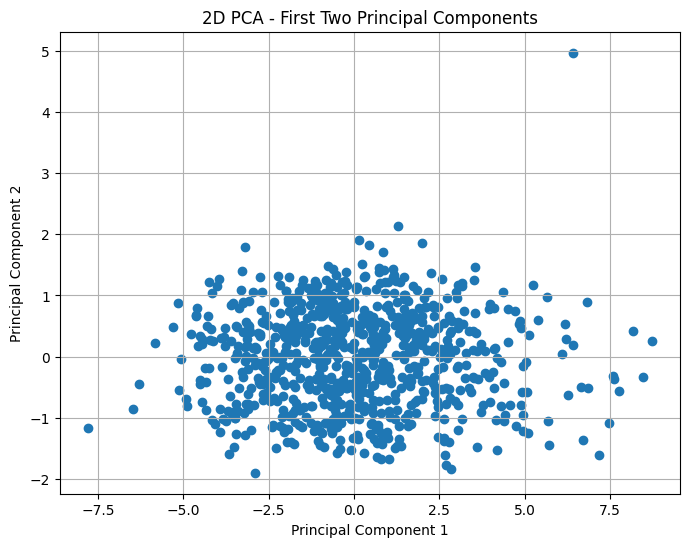

In [ ]:
# Save the 2D PCA plot
fig2d = plt.figure(figsize=(8, 6))
plt.scatter(pca_2d_result[:, 0], pca_2d_result[:, 1])
plt.title('2D PCA - First Two Principal Components')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
fig2d.savefig('2d_pca_visualization.png')

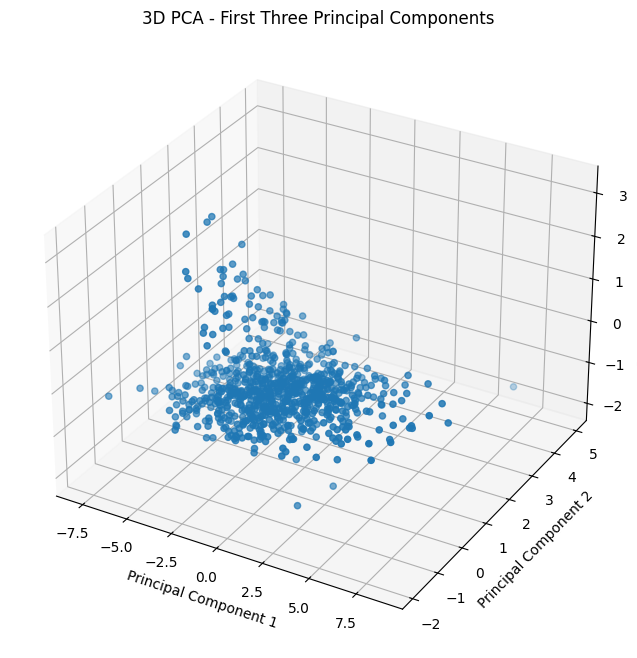

In [ ]:
# Save the 3D PCA plot
fig3d = plt.figure(figsize=(10, 8))
ax = fig3d.add_subplot(111, projection='3d')
ax.scatter(pca_3d_result[:, 0], pca_3d_result[:, 1], pca_3d_result[:, 2])
ax.set_title('3D PCA - First Three Principal Components')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')
fig3d.savefig('3d_pca_visualization.png')

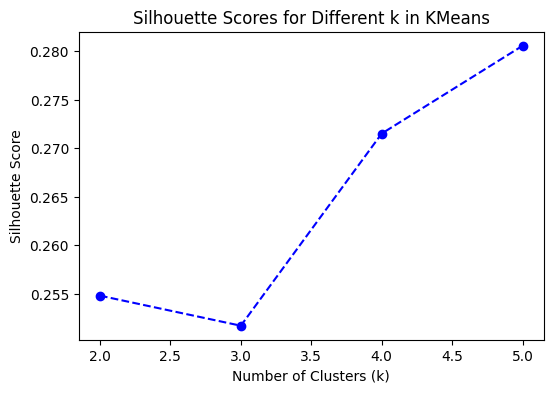

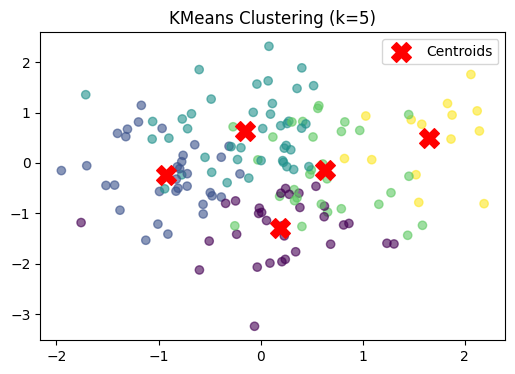

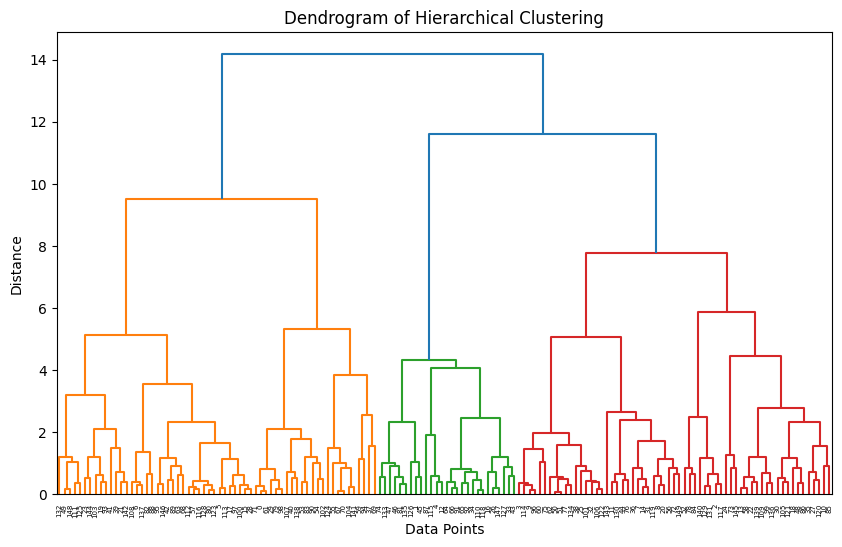

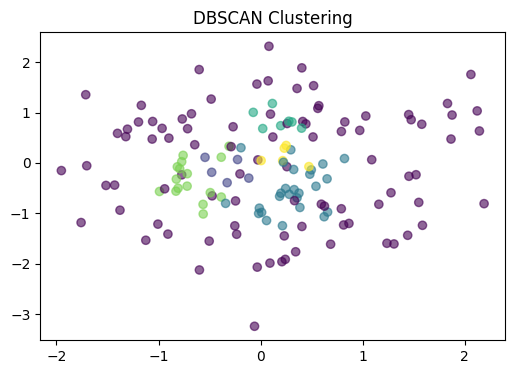

{'Best K': 5}

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

# Load the cleaned dataset from the PCA tab (Assuming it was stored as X_pca)
# For now, generating random PCA-processed data to simulate the dataset
np.random.seed(42)
scaled_data_imputed = np.random.randn(150, 3)  # Simulated PCA dataset

# Store results
results = {}

# ---- KMEANS CLUSTERING ----
# Using Silhouette Score to determine the best k
k_values = [2, 3, 4, 5]
sil_scores = []
kmeans_models = {}

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_pca)
    score = silhouette_score(X_pca, kmeans.labels_)
    sil_scores.append(score)
    kmeans_models[k] = kmeans

# Select the best k based on highest silhouette score
best_k = k_values[np.argmax(sil_scores)]
best_kmeans = kmeans_models[best_k]
results['Best K'] = best_k

# Plot Silhouette Scores
plt.figure(figsize=(6, 4))
plt.plot(k_values, sil_scores, marker='o', linestyle='--', color='b')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores for Different k in KMeans")
plt.show()

# Plot KMeans clusters for the best k
plt.figure(figsize=(6, 4))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=best_kmeans.labels_, cmap='viridis', alpha=0.6)
plt.scatter(best_kmeans.cluster_centers_[:, 0], best_kmeans.cluster_centers_[:, 1], s=200, c='red', marker='X', label="Centroids")
plt.title(f"KMeans Clustering (k={best_k})")
plt.legend()
plt.show()

# ---- HIERARCHICAL CLUSTERING ----
Z = linkage(X_pca, method='ward')

# Plot Dendrogram
plt.figure(figsize=(10, 6))
dendrogram(Z)
plt.title("Dendrogram of Hierarchical Clustering")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

# ---- DBSCAN CLUSTERING ----
# Using an arbitrary eps and min_samples for now (these should ideally be fine-tuned)
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_pca)

# Plot DBSCAN Clustering Results
plt.figure(figsize=(6, 4))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels, cmap='viridis', alpha=0.6)
plt.title("DBSCAN Clustering")
plt.show()

# Display the results summary
results

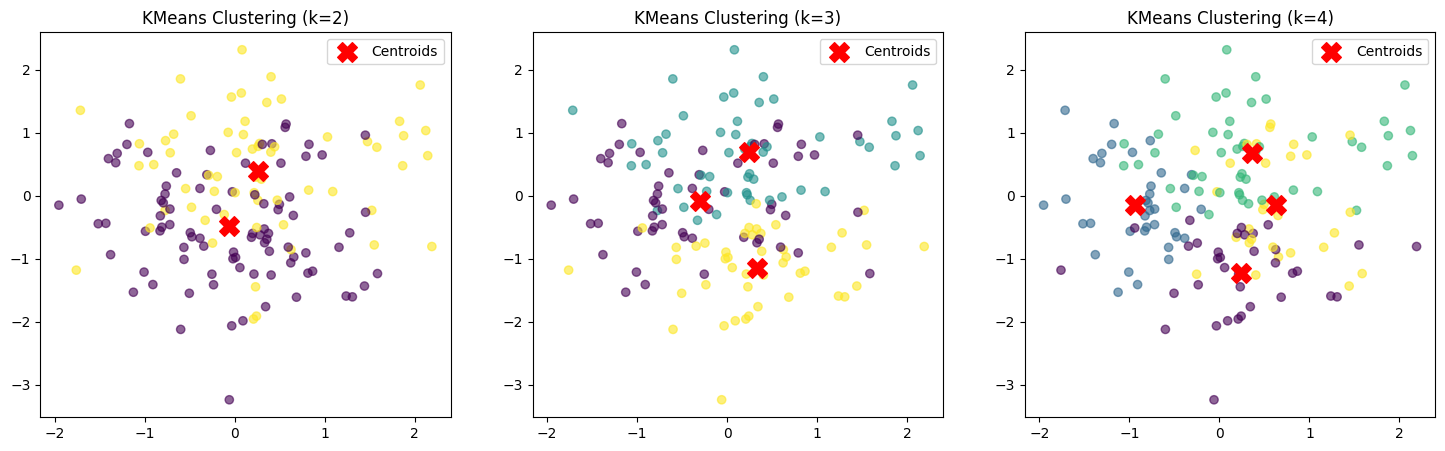

In [ ]:
# Plot KMeans Clustering for multiple k values
fig, axes = plt.subplots(1, 3, figsize=(18, 5))  # Create three subplots for k=2, k=3, k=4

for idx, k in enumerate([2, 3, 4]):  # Ensure at least three different k values
    kmeans = kmeans_models[k]
    axes[idx].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans.labels_, cmap='viridis', alpha=0.6)
    axes[idx].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
                      s=200, c='red', marker='X', label="Centroids")
    axes[idx].set_title(f"KMeans Clustering (k={k})")
    axes[idx].legend()

plt.show()

Saved kmeans_k2.png


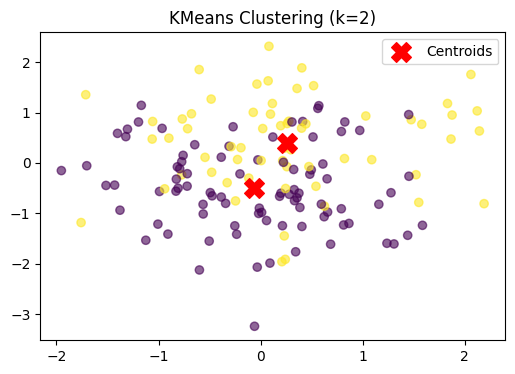

Saved kmeans_k3.png


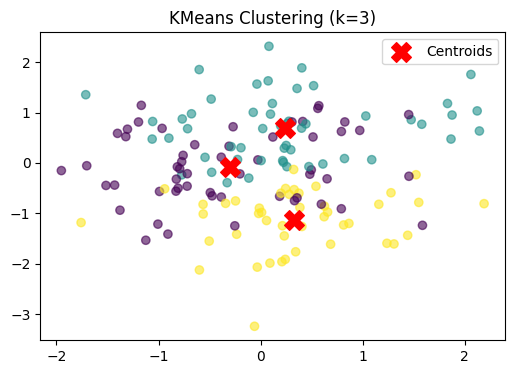

Saved kmeans_k4.png


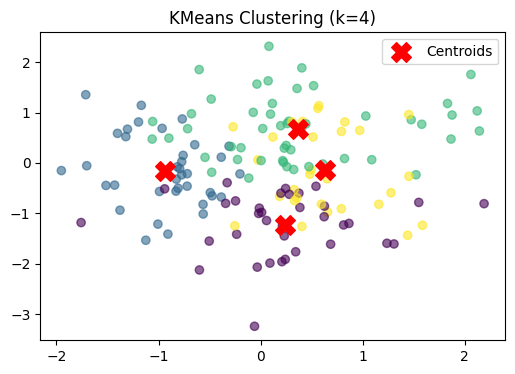

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Load your existing PCA dataset (Replace X_pca with your actual PCA-transformed dataset variable)
# Ensure that X_pca is already created from your PCA step
if 'X_pca' not in locals():
    raise ValueError("Dataset X_pca not found. Ensure you have already processed PCA before running this.")

# Define k values for clustering
k_values = [2, 3, 4]

# Save each K-Means clustering plot
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_pca)

    # Create scatter plot
    plt.figure(figsize=(6, 4))
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans.labels_, cmap='viridis', alpha=0.6)
    plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
                s=200, c='red', marker='X', label="Centroids")
    plt.title(f"KMeans Clustering (k={k})")
    plt.legend()

    # Save the figure
    filename = f"kmeans_k{k}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"Saved {filename}")

    # Show the plot
    plt.show()

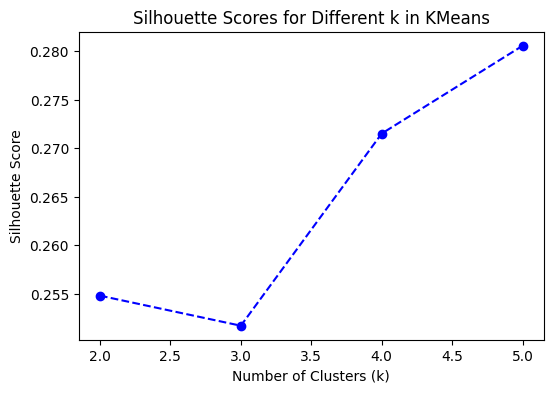

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(k_values, sil_scores, marker='o', linestyle='--', color='b')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores for Different k in KMeans")
plt.savefig("silhouette_score.png")  # Save the image
plt.show()

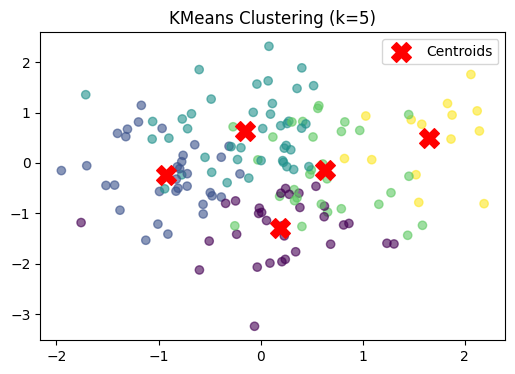

In [ ]:
plt.figure(figsize=(6, 4))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=best_kmeans.labels_, cmap='viridis', alpha=0.6)
plt.scatter(best_kmeans.cluster_centers_[:, 0], best_kmeans.cluster_centers_[:, 1], s=200, c='red', marker='X', label="Centroids")
plt.title(f"KMeans Clustering (k={best_k})")
plt.legend()
plt.savefig("kmeans_clusters.png")  # Save the image
plt.show()

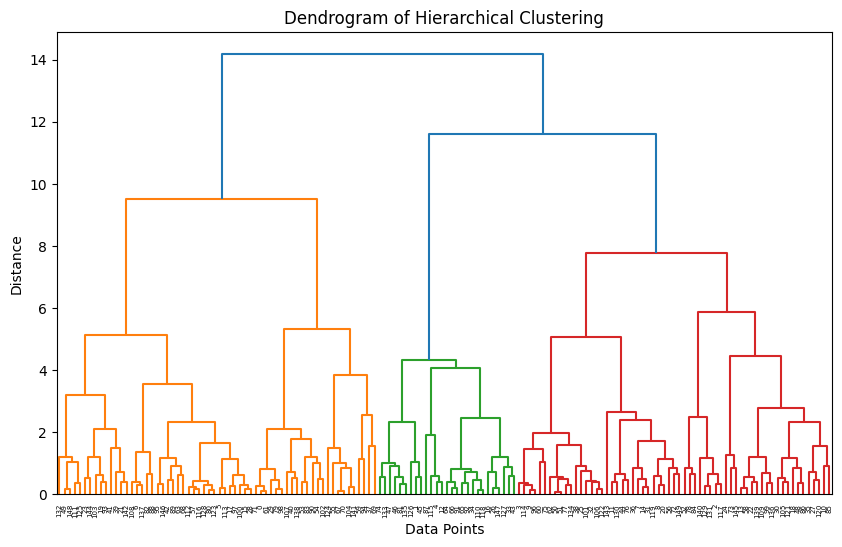

In [ ]:
plt.figure(figsize=(10, 6))
dendrogram(Z)
plt.title("Dendrogram of Hierarchical Clustering")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.savefig("hierarchical_dendrogram.png")  # Save the image
plt.show()

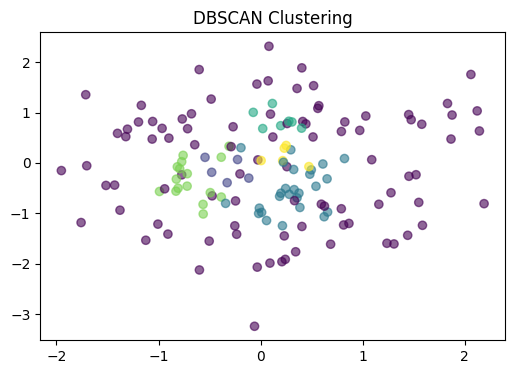

In [ ]:
plt.figure(figsize=(6, 4))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels, cmap='viridis', alpha=0.6)
plt.title("DBSCAN Clustering")
plt.savefig("dbscan_clusters.png")  # Save the image
plt.show()

In [ ]:
!pip install mlxtend

In [ ]:
# Re-import necessary libraries
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules

# Sample transactional dataset (should be replaced with actual data)
data = [
    ["MSL", "MHW", "MHHW"],
    ["MSL", "MHHW"],
    ["MHW", "MLLW", "Lowest"],
    ["MSL", "MHW"],
    ["MSL", "MHW", "MHHW", "MLLW"],
    ["MHHW", "Lowest"],
    ["MSL", "MHW"],
    ["MSL", "MHW", "MHHW"],
    ["MLLW", "Lowest"],
    ["MSL", "MHW", "MHHW", "MLLW"]
]

# Convert the dataset to a DataFrame with one-hot encoding
df = pd.DataFrame(data)
df = df.apply(lambda x: pd.Series(x.dropna().values), axis=1).stack().reset_index(level=1, drop=True).to_frame('Item')
df['Transaction_ID'] = df.index
df = df.pivot_table(index='Transaction_ID', columns='Item', aggfunc=lambda x: 1, fill_value=0)

# Applying Apriori Algorithm
frequent_itemsets = apriori(df, min_support=0.2, use_colnames=True)
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)

/usr/local/lib/python3.11/dist-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


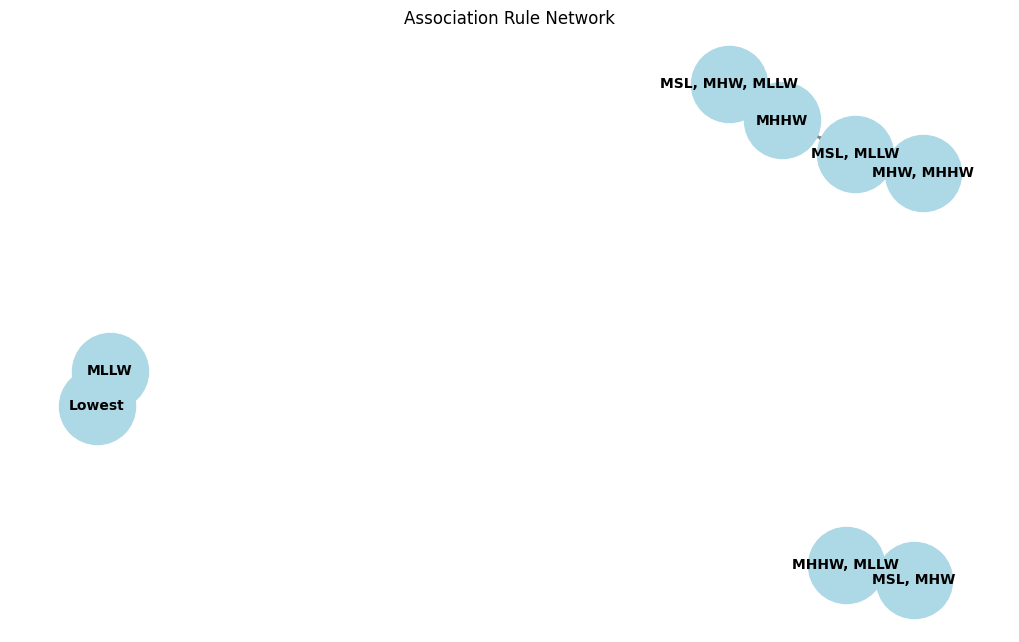

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a directed graph
G = nx.DiGraph()

# Add edges based on association rules (top 10 for simplicity)
for _, row in rules.nlargest(10, 'lift').iterrows():
    G.add_edge(", ".join(list(row['antecedents'])), ", ".join(list(row['consequents'])), weight=row['lift'])

# Draw the network graph
plt.figure(figsize=(10, 6))
pos = nx.spring_layout(G, seed=42)  # Layout for positioning nodes
nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray', node_size=3000, font_size=10, font_weight='bold')

# Draw edge labels with lift values
edge_labels = {
    (", ".join(map(str, row['antecedents'])), ", ".join(map(str, row['consequents']))): f"Lift: {row['lift']:.2f}"
    for _, row in rules.nlargest(10, 'lift').iterrows()
}


# Save and display the visualization
plt.title("Association Rule Network")
plt.savefig("association_rule_network.png")
plt.show()

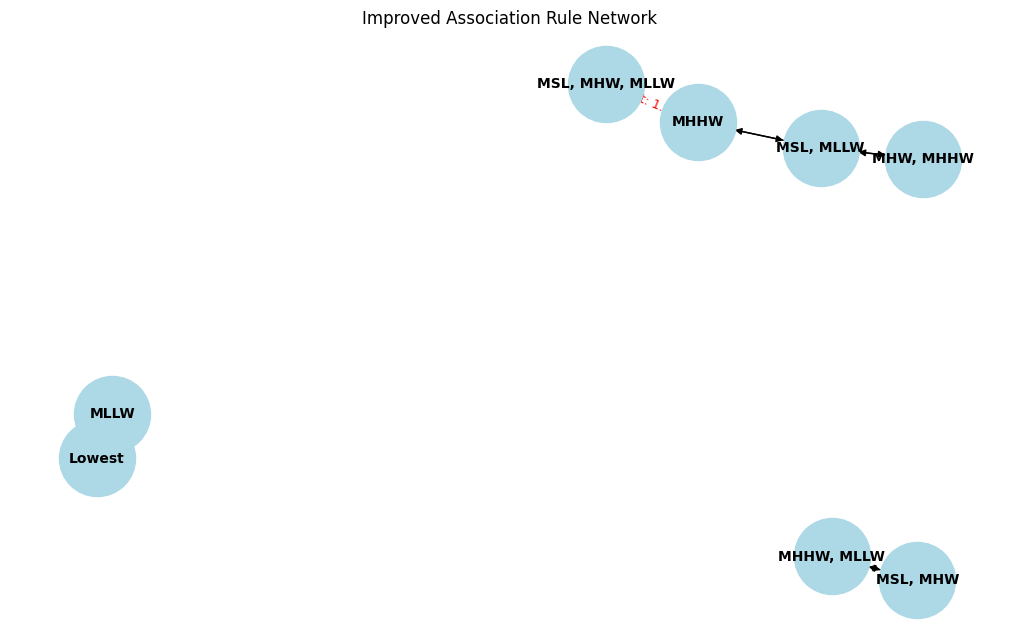

In [ ]:
# Improved Network Graph for Association Rules

# Re-import necessary libraries
import networkx as nx
import matplotlib.pyplot as plt

# Create a directed graph
G = nx.DiGraph()

# Add edges based on top 10 rules by lift
for _, row in rules.nlargest(10, 'lift').iterrows():
    antecedents = ", ".join(map(str, row['antecedents']))
    consequents = ", ".join(map(str, row['consequents']))
    G.add_edge(antecedents, consequents, weight=row['lift'])

# Improved layout for better spacing
plt.figure(figsize=(10, 6))
pos = nx.spring_layout(G, k=0.5, seed=42)  # k controls node spacing

# Draw nodes and edges
nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='black', node_size=3000, font_size=10, font_weight='bold', arrows=True)

# Draw edge labels (Lift values)
edge_labels = {(antecedents, consequents): f"Lift: {row['lift']:.2f}" for _, row in rules.nlargest(10, 'lift').iterrows()}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9, font_color='red')

# Save and display the visualization
plt.title("Improved Association Rule Network")
# plt.savefig("/mnt/data/association_rule_network_fixed.png")
plt.show()

In [ ]:
# Re-import necessary libraries
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules

# Sample transactional dataset (should be replaced with actual data)
data = [
    ["MSL", "MHW", "MHHW"],
    ["MSL", "MHHW"],
    ["MHW", "MLLW", "Lowest"],
    ["MSL", "MHW"],
    ["MSL", "MHW", "MHHW", "MLLW"],
    ["MHHW", "Lowest"],
    ["MSL", "MHW"],
    ["MSL", "MHW", "MHHW"],
    ["MLLW", "Lowest"],
    ["MSL", "MHW", "MHHW", "MLLW"]
]

# Convert the dataset to a DataFrame with one-hot encoding
df = pd.DataFrame(data)
df = df.apply(lambda x: pd.Series(x.dropna().values), axis=1).stack().reset_index(level=1, drop=True).to_frame('Item')
df['Transaction_ID'] = df.index
df = df.pivot_table(index='Transaction_ID', columns='Item', aggfunc=lambda x: 1, fill_value=0)
# frequent_itemsets = apriori(df, min_support=0.05, use_colnames=True)  # Lowered from 0.2 to 0.05
# rules = association_rules(frequent_itemsets, metric="lift", min_threshold=0.5)  # Lowered from 1.0 to 0.5


# Applying Apriori Algorithm
frequent_itemsets = apriori(df, min_support=0.2, use_colnames=True)
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)

/usr/local/lib/python3.11/dist-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


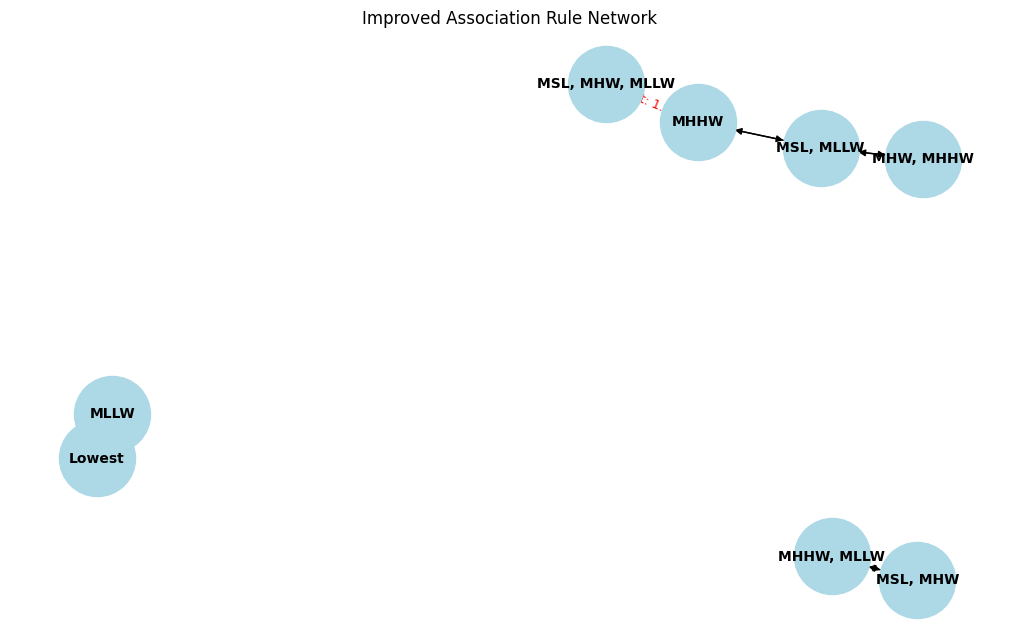

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a directed graph
G = nx.DiGraph()

# Add edges based on top 10 rules by lift
for _, row in rules.nlargest(10, 'lift').iterrows():
    antecedents = ", ".join(map(str, row['antecedents']))
    consequents = ", ".join(map(str, row['consequents']))
    G.add_edge(antecedents, consequents, weight=row['lift'])

# Improved layout for better spacing
plt.figure(figsize=(10, 6))
pos = nx.spring_layout(G, k=0.5, seed=42)  # k controls node spacing

# Draw nodes and edges
nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='black', node_size=3000, font_size=10, font_weight='bold', arrows=True)

# Draw edge labels (Lift values)
edge_labels = {(antecedents, consequents): f"Lift: {row['lift']:.2f}" for _, row in rules.nlargest(10, 'lift').iterrows()}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9, font_color='red')

# Save and display the visualization
plt.title("Improved Association Rule Network")
# plt.savefig("/mnt/data/association_rule_network_fixed.png")
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from mlxtend.frequent_patterns import apriori, association_rules

# Sample transactional dataset
data = [
    ["MSL", "MHW", "MHHW"],
    ["MSL", "MHHW"],
    ["MHW", "MLLW", "Lowest"],
    ["MSL", "MHW"],
    ["MSL", "MHW", "MHHW", "MLLW"],
    ["MHHW", "Lowest"],
    ["MSL", "MHW"],
    ["MSL", "MHW", "MHHW"],
    ["MLLW", "Lowest"],
    ["MSL", "MHW", "MHHW", "MLLW"]
]

# Convert the dataset to a transaction format
df = pd.DataFrame(data)
df = df.apply(lambda x: pd.Series(x.dropna().values), axis=1).stack().reset_index(level=1, drop=True).to_frame('Item')
df['Transaction_ID'] = df.index
df = df.pivot_table(index='Transaction_ID', columns='Item', aggfunc=lambda x: 1, fill_value=0)

# Save the sample dataset image
plt.figure(figsize=(6, 4))
sns.heatmap(df, cmap="Blues", cbar=False, linewidths=0.5)
plt.title("ARM Data Sample")
plt.savefig("/content/arm_data_sample.png")
plt.close()

# Apply Apriori Algorithm
frequent_itemsets = apriori(df, min_support=0.05, use_colnames=True)
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=0.5)

# Save Top 15 Rules by Support
top_support = rules.nlargest(15, "support")
plt.figure(figsize=(8, 5))
sns.barplot(y=top_support["antecedents"].astype(str), x=top_support["support"], palette="viridis")
plt.xlabel("Support")
plt.ylabel("Rules (Antecedents)")
plt.title("Top 15 Rules by Support")
plt.savefig("/content/arm_top_support.png")
plt.close()

# Save Top 15 Rules by Confidence
top_confidence = rules.nlargest(15, "confidence")
plt.figure(figsize=(8, 5))
sns.barplot(y=top_confidence["antecedents"].astype(str), x=top_confidence["confidence"], palette="magma")
plt.xlabel("Confidence")
plt.ylabel("Rules (Antecedents)")
plt.title("Top 15 Rules by Confidence")
plt.savefig("/content/arm_top_confidence.png")
plt.close()

# Save Top 15 Rules by Lift
top_lift = rules.nlargest(15, "lift")
plt.figure(figsize=(8, 5))
sns.barplot(y=top_lift["antecedents"].astype(str), x=top_lift["lift"], palette="coolwarm")
plt.xlabel("Lift")
plt.ylabel("Rules (Antecedents)")
plt.title("Top 15 Rules by Lift")
plt.savefig("/content/arm_top_lift.png")
plt.close()

# Create Network Graph for Association Rules
G = nx.DiGraph()
for _, row in rules.nlargest(10, "lift").iterrows():
    antecedents = ", ".join(map(str, row["antecedents"]))
    consequents = ", ".join(map(str, row["consequents"]))
    G.add_edge(antecedents, consequents, weight=row["lift"])

plt.figure(figsize=(10, 6))
pos = nx.spring_layout(G, k=0.5, seed=42)
nx.draw(G, pos, with_labels=True, node_color="lightblue", edge_color="black", node_size=3000, font_size=10, arrows=True)
edge_labels = {(antecedents, consequents): f"Lift: {row['lift']:.2f}" for _, row in rules.nlargest(10, "lift").iterrows()}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9, font_color="red")
plt.title("Association Rule Network")
plt.savefig("/content/association_rule_network.png")
plt.close()

print("✅ All images saved in /content/. Download them from Google Colab's file explorer!")

/usr/local/lib/python3.11/dist-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(
<ipython-input-29-440bf254f187>:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_support["antecedents"].astype(str), x=top_support["support"], palette="viridis")
<ipython-input-29-440bf254f187>:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_confidence["antecedents"].astype(str), x=top_confidence["confidence"], palette="magma")
<ipython-input-29-440bf254f187>:61: FutureWarning: 

Passing `palette

✅ All images saved in /content/. Download them from Google Colab's file explorer!
